In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("Placement_Company_Selects_Salary_Batch.xlsx")

In [4]:
df.head()

,Company Name,Selects,Salary(LPA),Batch
0,WIRPO,6,3.5,2019-20
1,MINDTREE,2,3.5,2019-20
2,JARO EDUCATION,1,12.0,2019-20
3,Gallagher,36,2.4,2019-20
4,Grant Thornton,3,4.5,2019-20


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company Name  207 non-null    object 
 1   Selects       207 non-null    int64  
 2   Salary(LPA)   207 non-null    float64
 3   Batch         207 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.6+ KB


In [6]:
df.describe(include="all")

,Company Name,Selects,Salary(LPA),Batch
count,207,207.000000,207.000000,207
unique,180,NaN,NaN,6
top,TCS,NaN,NaN,2020-21
freq,4,NaN,NaN,43
mean,NaN,11.623188,4.331184,NaN
std,NaN,17.681185,1.997043,NaN
min,NaN,1.000000,1.800000,NaN
25%,NaN,2.000000,3.100000,NaN
50%,NaN,5.000000,3.750000,NaN
75%,NaN,14.000000,5.000000,NaN


In [7]:
df.isnull().sum()

Company Name    0
Selects         0
Salary(LPA)     0
Batch           0
dtype: int64

In [8]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [9]:
df.columns

Index(['company_name', 'selects', 'salary(lpa)', 'batch'], dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

company_name     object
selects           int64
salary(lpa)     float64
batch            object
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  207 non-null    object 
 1   selects       207 non-null    int64  
 2   salary(lpa)   207 non-null    float64
 3   batch         207 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.6+ KB


In [13]:
print("Batches:")
print(df['batch'].unique())

print("\nCompanies:")
print(df['company_name'].nunique())

Batches:
['2019-20' '2020-21' '2021-22' '2022-23' '2023-24' '2025-26']

Companies:
180


In [14]:
print("Total students selected:", df['selects'].sum())

print("Average Salary:", df['salary(lpa)'].mean())

print("Highest Salary:", df['salary(lpa)'].max())

print("Lowest Salary:", df['salary(lpa)'].min())

Total students selected: 2406
Average Salary: 4.331183574879227
Highest Salary: 12.75
Lowest Salary: 1.8


In [15]:

batch_selections = df.groupby('batch')['selects'].sum().sort_index()

batch_selections

batch
2019-20    454
2020-21    421
2021-22    419
2022-23    407
2023-24    276
2025-26    429
Name: selects, dtype: int64

In [16]:
import matplotlib.pyplot as plt

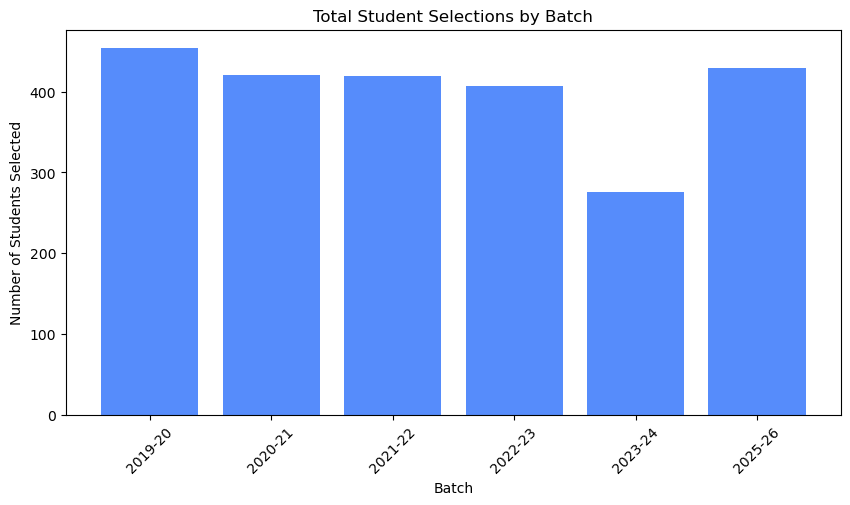

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(batch_selections.index, batch_selections.values)

plt.title("Total Student Selections by Batch")
plt.xlabel("Batch")
plt.ylabel("Number of Students Selected")

plt.xticks(rotation=45)
plt.show()

In [18]:

batch_salary = df.groupby('batch')['salary(lpa)'].mean().sort_index()

batch_salary

batch
2019-20    3.833750
2020-21    4.091163
2021-22    4.373649
2022-23    4.735833
2023-24    5.496875
2025-26    3.738710
Name: salary(lpa), dtype: float64

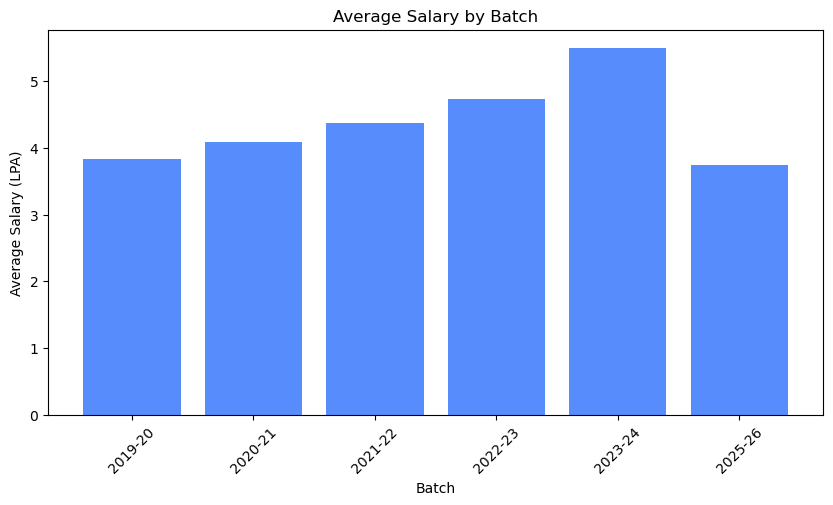

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(batch_salary.index, batch_salary.values)

plt.title("Average Salary by Batch")
plt.xlabel("Batch")
plt.ylabel("Average Salary (LPA)")

plt.xticks(rotation=45)
plt.show()

In [20]:

top_companies = (
    df.groupby('company_name')['selects']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_companies

company_name
SEDEMAC                        164
Cognizant                       95
TCS                             91
HEALTHPLIX TECHNOLOGIES         88
JUST DIAL                       73
Leit Motif Solutions            67
Infipre Goa                     66
Ronch Polymers Pvt Ltd Pune     60
L&T                             59
Minfy                           54
Name: selects, dtype: int64

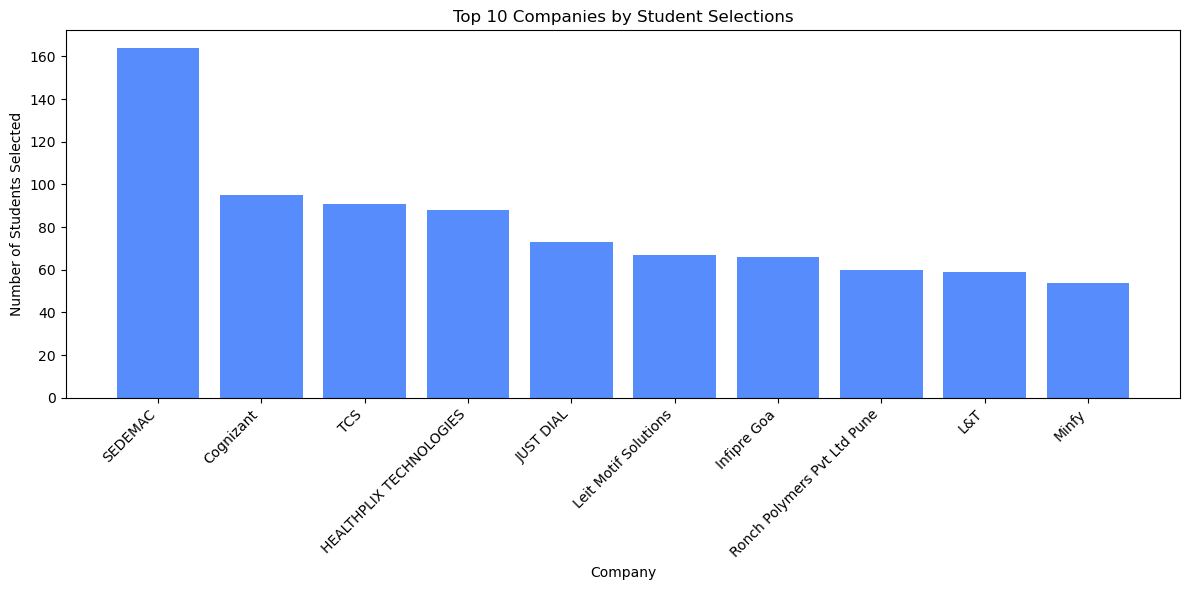

In [21]:
plt.figure(figsize=(12, 6))

plt.bar(top_companies.index, top_companies.values)

plt.title("Top 10 Companies by Student Selections")
plt.xlabel("Company")
plt.ylabel("Number of Students Selected")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [22]:
top_salary_companies = (
    df.groupby('company_name')['salary(lpa)']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_salary_companies

company_name
AMADEUS           12.75
EXTRAMARKS        12.50
ORACLE            12.50
Federal Bank      12.00
JARO EDUCATION    12.00
Brillio           11.25
MCAFEE            10.00
BYJUS             10.00
GE APPLIANCES      9.00
Hashedin           8.10
Name: salary(lpa), dtype: float64

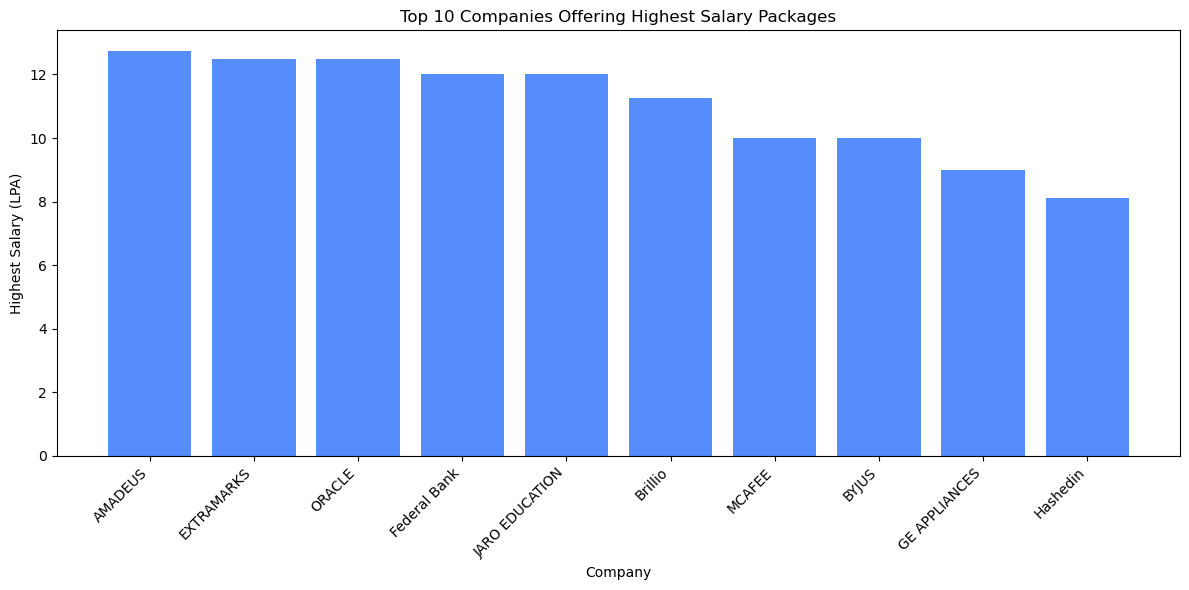

In [23]:
plt.figure(figsize=(12, 6))

plt.bar(top_salary_companies.index, top_salary_companies.values)

plt.title("Top 10 Companies Offering Highest Salary Packages")
plt.xlabel("Company")
plt.ylabel("Highest Salary (LPA)")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

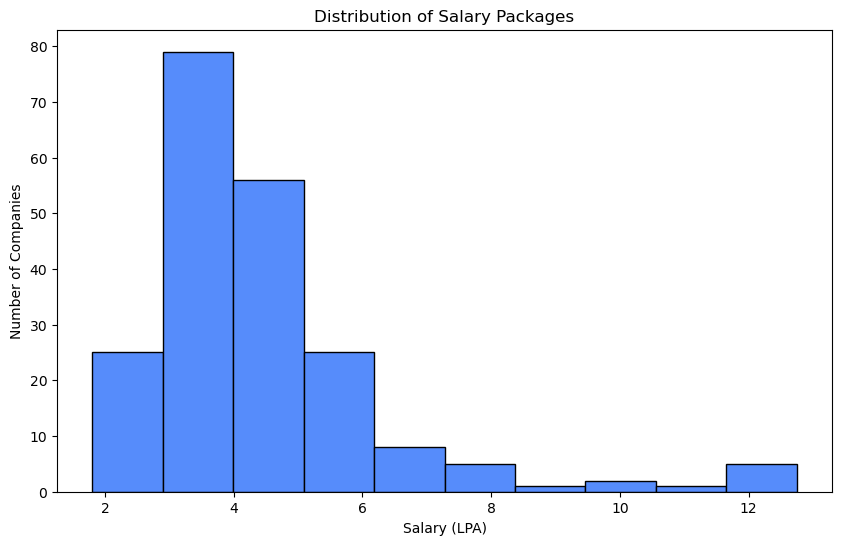

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(df['salary(lpa)'], bins=10, edgecolor='black')

plt.title("Distribution of Salary Packages")
plt.xlabel("Salary (LPA)")
plt.ylabel("Number of Companies")

plt.show()

In [25]:
df['salary(lpa)'].describe()

count    207.000000
mean       4.331184
std        1.997043
min        1.800000
25%        3.100000
50%        3.750000
75%        5.000000
max       12.750000
Name: salary(lpa), dtype: float64

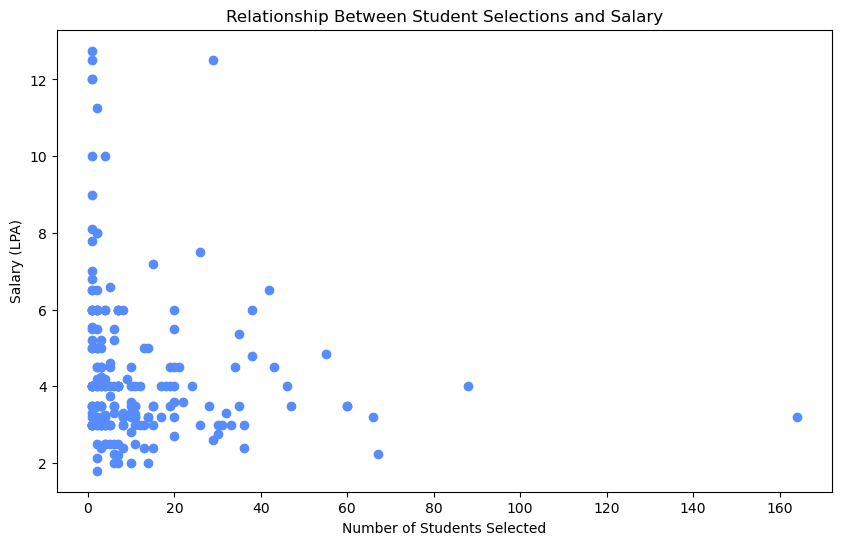

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(df['selects'], df['salary(lpa)'])

plt.title("Relationship Between Student Selections and Salary")
plt.xlabel("Number of Students Selected")
plt.ylabel("Salary (LPA)")

plt.show()

In [27]:
correlation = df['selects'].corr(df['salary(lpa)'])

print("Correlation between Selections and Salary:", correlation)

Correlation between Selections and Salary: -0.13285387204043056


In [39]:
!pip install pymysql sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
%pip install pymysql


  Using cached pymysql-1.2.0-py3-none-any.whl.metadata (4.3 kB)
Using cached pymysql-1.2.0-py3-none-any.whl (45 kB)


In [41]:
import pymysql
print("yes")

yes


In [46]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = "Sachin@2005"
host = "localhost"
port = "3306"
database = "placement_analysis"


password_encoded = quote_plus(password)

engine = create_engine(
    f"mysql+pymysql://{username}:{password_encoded}@{host}:{port}/{database}"
)

In [47]:
table_name = "placement_data"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print("Data loaded successfully")

Data loaded successfully
